# TS3:"Analisis de Fourier: FFT, desparramo, interpolacion y ventaneo."

## Alumno: Suarez Lucila

En esta tarea semanal se analizara el efecto de desparramo espectral, que se da al calcular la DFT. Se nos pidio usar una senoidal con una frecuencia f0=k0.f2/N=k0.$\Delta f$ y poner una potencia normalizada, es decir energia (o varianza) unitaria. Tuvimos que variar la k0 agregandole una pequeña desintonia respecto a $\Delta f$. Luego, se nos pidio verificar la potencia unitaria de cada PSD, en donde usamos la identidad de Parseval. Para finalizar, repetimos el experimento pero usando la tecnica zero padding. 

Primero comenzamos definiendo las variables y llamando a la señal senoidal.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
#from scipy.stats import kstest


#%% 1. FUNCIÓN SENOIDAL
def funcion_sen(A=1, Vmed=0, ff=1, phi=0, nn=1000, fs=1000):
    tt = np.arange(nn) / fs
    xx = A * np.sin(2 * np.pi * ff * tt + phi) + Vmed
    return tt, xx
 
#%% 2. PARÁMETROS GENERALES
Ps = 1 # potencia de la senoidal (normalizada a 1W)
Amplitud = np.sqrt(2*Ps)
Vmed = 0
phi = 0
N = 1000
fs = 1000
k0 = N/4 # desp sumarle 0.25 y 0.5
ff = k0 * (fs/N)
 
#%% 3. SEÑAL SENOIDAL
tt, xx = funcion_sen(Amplitud, Vmed, ff, phi, N, fs)
 
fft_seno = np.fft.fft(xx)/N #/N para normalizarlo

modulo_sen = np.abs(fft_seno)

#%% 4. FRECUENCIAS HASTA NYQUIST
frecuencias = np.fft.fftfreq(N, 1/fs)
corte = N // 2
frec_nyquist = frecuencias[:corte]

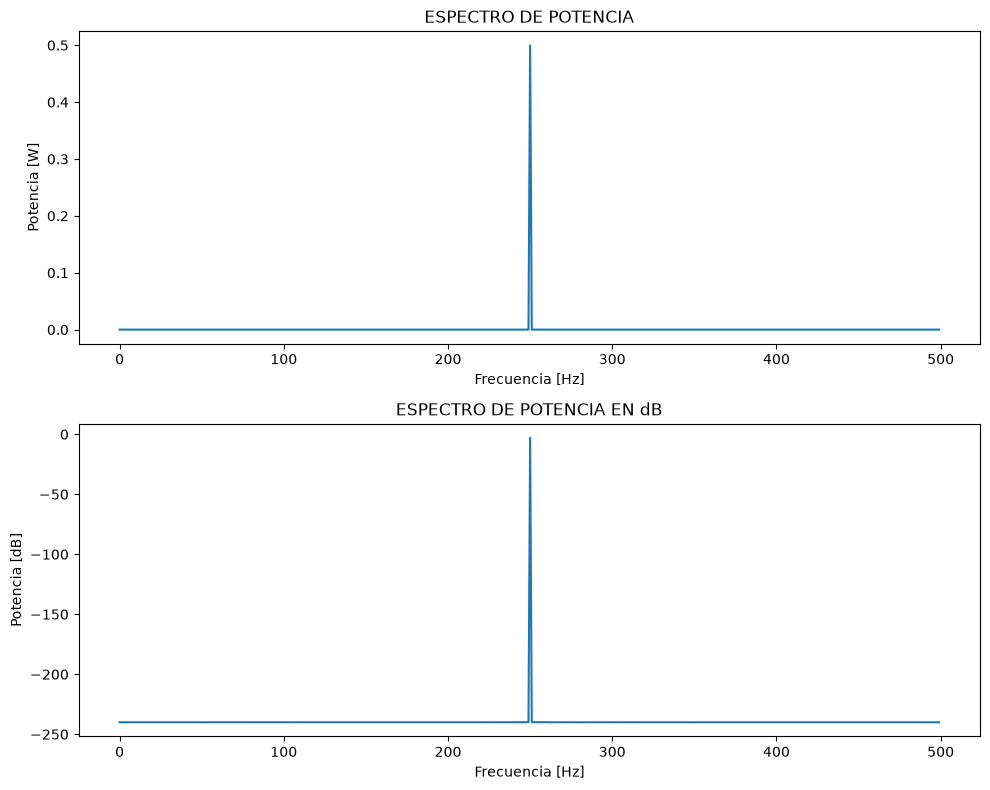

In [27]:
#%% GRAFICO
plt.figure(1, figsize=(10,8))

## k = N/4
plt.subplot(2,1,1)
plt.title("ESPECTRO DE POTENCIA")
plt.plot(frec_nyquist, (modulo_sen[:corte])**2, label='k = N/4')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [W]")
plt.subplot(2,1,2)
plt.title("ESPECTRO DE POTENCIA EN dB")
plt.plot(frec_nyquist, 20*np.log10(modulo_sen[:corte] + 1e-12), label='k = N/4')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.tight_layout()

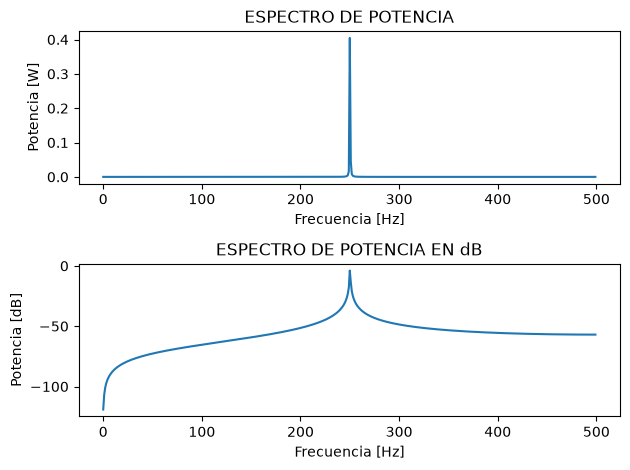

In [28]:
## k = N/4 + 0.25
k1 = (N/4) + 0.25
f1 = k1 * (fs/N)
tt, x1 = funcion_sen(Amplitud, Vmed, f1, phi, N, fs)
fft_seno1 = np.fft.fft(x1)/N
modulo_sen1 = np.abs(fft_seno1)

plt.subplot(2,1,1)
plt.title("ESPECTRO DE POTENCIA")
plt.plot(frec_nyquist, (modulo_sen1[:corte])**2, label='k = N/4 + 0.25')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [W]")
plt.subplot(2,1,2)
plt.title("ESPECTRO DE POTENCIA EN dB")
plt.plot(frec_nyquist, 20*np.log10(modulo_sen1[:corte] + 1e-12), label='k = N/4 + 0.25')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.tight_layout()

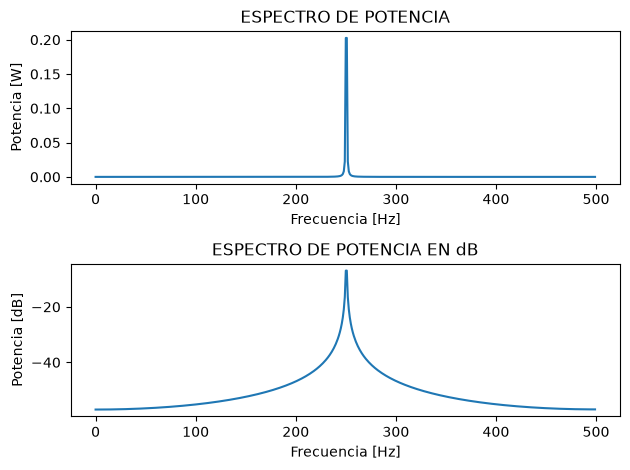

In [29]:
## k = N/4 + 0.5
k2 = (N/4) + 0.5
f2 = k2 * (fs/N)
tt, x2 = funcion_sen(Amplitud, Vmed, f2, phi, N, fs)
fft_seno2 = np.fft.fft(x2)/N
modulo_sen2 = np.abs(fft_seno2)

plt.subplot(2,1,1)
plt.title("ESPECTRO DE POTENCIA")
plt.plot(frec_nyquist, (modulo_sen2[:corte])**2, label='k = N/4 + 0.5')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [W]")
plt.subplot(2,1,2)
plt.title("ESPECTRO DE POTENCIA EN dB")
plt.plot(frec_nyquist, 20*np.log10(modulo_sen2[:corte] + 1e-12), label='k = N/4 + 0.5')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.tight_layout()

Para esta primera parte del experimento pudimos observar como cambiaba el efecto de desparramo a medida que le sumábamos a k0 una desintonia respecto a $\Delta f$. Cuando la frecuencia coincidía con un bin entero de DFT (k0=N/4), no existía desparramo. Conforme empezamos a sumarle a K0 lo dicho, la frecuencia deja de coincidir con un bin y se comienza a observar el desparramo. 

Luego verificamos la potencia unitaria de cada PSD, esto lo hicimos usando la identidad de Parseval.

In [30]:
potencia_tiempo = np.mean(xx**2)
potencia_tiempo1 = np.mean(x1**2)
potencia_tiempo2 = np.mean(x2**2)

# Potencia calculada desde la FFT (Parseval):
potencia_frecuencia = np.sum(np.abs(fft_seno)**2)
potencia_frecuencia1 = np.sum(np.abs(fft_seno1)**2)
potencia_frecuencia2 = np.sum(np.abs(fft_seno2)**2)

print(f"Potencia en el tiempo 0: {potencia_tiempo}")
print(f"Potencia en el tiempo 1: {potencia_tiempo1}")
print(f"Potencia en el tiempo 2: {potencia_tiempo2}")


print(f"Potencia en frecuencia 0 (Parseval): {potencia_frecuencia}")
print(f"Potencia en frecuencia 1 (Parseval): {potencia_frecuencia1}")
print(f"Potencia en frecuencia 2 (Parseval): {potencia_frecuencia2}")

Potencia en el tiempo 0: 1.0000000000000002
Potencia en el tiempo 1: 0.9989999999999998
Potencia en el tiempo 2: 1.0000000000000004
Potencia en frecuencia 0 (Parseval): 1.0000000000000002
Potencia en frecuencia 1 (Parseval): 0.9989999999999997
Potencia en frecuencia 2 (Parseval): 1.0000000000000007


Con los resultados que obtuvimos en el apartado de arriba pudimos verificar la potencia unitaria de cada PSD. Por un lado, podemos decir que cuando no hay desparramo la potencia se concentra en un único bin. Por otro lado, vemos como  la potencia disminuia, ya que, la energía restante se desparrama hacia las demás frecuencias. 

Para finalizar, repetimos el experimento mediante la tecnica 'zero padding', que consistio en agregar ceros al final de la señal para aumentar $\Delta f$.

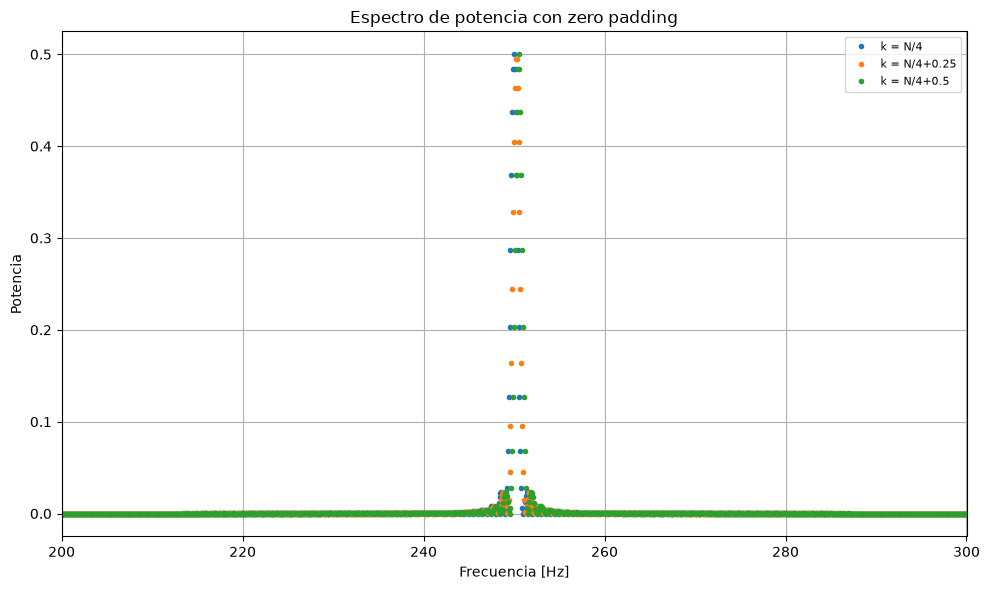

In [31]:
zeros=np.zeros(9*N)
xx_zeros=np.concatenate((xx, zeros))
x1_zeros=np.concatenate((x1, zeros))
x2_zeros=np.concatenate((x2, zeros))

N_pad = N + 9*N  # 10*N muestras
frecuencias_pad = np.fft.fftfreq(N_pad, 1/fs)
corte_pad = N_pad // 2
frec_nyquist_pad = frecuencias_pad[:corte_pad]

## fft con Zero Padding
fft_xxz= (1/N) * np.fft.fft(xx_zeros)
fft_x1z= (1/N) * np.fft.fft(x1_zeros)
fft_x2z= (1/N) * np.fft.fft(x2_zeros)

plt.figure(figsize=(10,6))
plt.plot(frec_nyquist_pad, (np.abs(fft_xxz[:corte_pad]))**2, ".", label='k = N/4')
plt.plot(frec_nyquist_pad, (np.abs(fft_x1z[:corte_pad]))**2, ".", label='k = N/4+0.25')
plt.plot(frec_nyquist_pad, (np.abs(fft_x2z[:corte_pad]))**2, ".", label='k = N/4+0.5')

plt.title("Espectro de potencia con zero padding")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia")
plt.legend(fontsize=8)
plt.grid(True)
plt.xlim(200, 300)  # zoom cerca del pico para ver bien el desparramo
plt.tight_layout()
plt.show()


plt.show()

Con la tecnica "zero padding", ya no se ve la delta. Al calcular la DFT con 9N ceros agregado, se "rellenan" los espacion intermedios entre los bins originales; podemos decir que el "zero padding" funciona como una interpolación.
A su vez, observamos como las 3 señales se comportan de manera parecida, estando únicamente desplazadas en frecuencias.

En conclusión, al ver que las potencias se conservaron sin importar si se le sumaba a k0 una desintonia; demostramos que el desparramo no destruye la energía, si no que, la redistribuye entre los distintos bins. 
La adicion de ceros al final de la señal redujo el paso frecuencial, funcionando como una interpolación en la frecuencia. 